# Exploratory data analysis

Explores the validated Edmonton two-bedroom master dataset (`data/processed/edmonton_2br_master.csv`) and the population and unemployment context series. The findings here motivated the lag features used in `03_forecasting.ipynb`.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
master = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "edmonton_2br_master.csv")
master.head()

,year,average_rent,vacancy_rate
0,2000,603.0,1.3
1,2001,657.0,0.9
2,2002,710.0,1.6
3,2003,723.0,3.5
4,2004,729.0,5.2


## Summary statistics

In [2]:
growth = (master["average_rent"].iloc[-1] / master["average_rent"].iloc[0]) ** (1 / (len(master) - 1)) - 1
print(f"Rent: ${master['average_rent'].iloc[0]:,.0f} (2000) → ${master['average_rent'].iloc[-1]:,.0f} (2025)")
print(f"Compound annual growth: {growth:.2%}")
master[["average_rent", "vacancy_rate"]].describe().round(2)

Rent: $603 (2000) → $1,598 (2025)
Compound annual growth: 3.98%


,average_rent,vacancy_rate
count,26.00,26.00
mean,1079.54,3.61
std,273.24,1.96
min,603.00,0.90
25%,848.50,1.70
50%,1109.00,3.65
75%,1260.25,4.78
max,1598.00,7.10


## Year-over-year rent change

Growth comes in bursts: 2006–2008, 2013–2014, and 2023–2025, with declines in 2009 and 2016–2017.

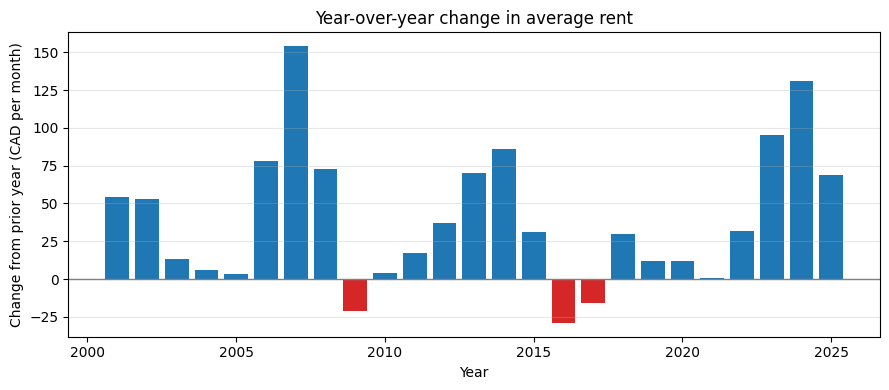

,year,rent_change,rent_change_pct
7,2007,154.0,19.012346
24,2024,131.0,9.370529
23,2023,95.0,7.290867
14,2014,86.0,7.517483
6,2006,78.0,10.655738


In [3]:
master["rent_change"] = master["average_rent"].diff()
master["rent_change_pct"] = master["average_rent"].pct_change() * 100

changes = master.dropna(subset=["rent_change"])
colors = ["tab:blue" if value >= 0 else "tab:red" for value in changes["rent_change"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(changes["year"], changes["rent_change"], color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Year-over-year change in average rent")
ax.set_xlabel("Year")
ax.set_ylabel("Change from prior year (CAD per month)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

changes.nlargest(5, "rent_change")[["year", "rent_change", "rent_change_pct"]]

## Vacancy rate

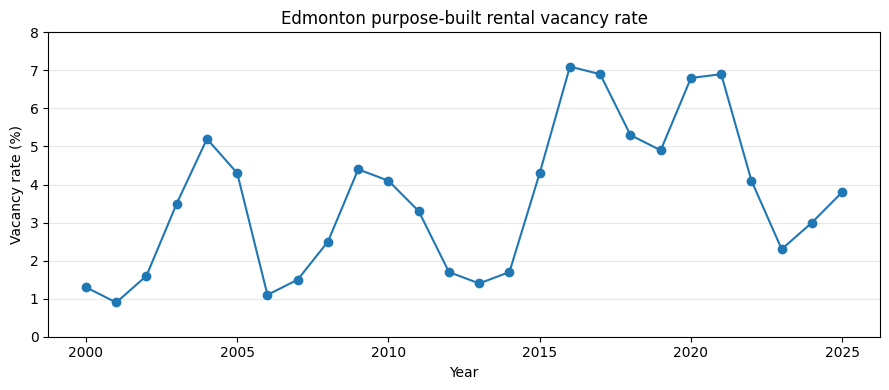

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(master["year"], master["vacancy_rate"], marker="o")
ax.set_title("Edmonton purpose-built rental vacancy rate")
ax.set_xlabel("Year")
ax.set_ylabel("Vacancy rate (%)")
ax.set_ylim(0, 8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Does last year's vacancy predict this year's rent growth?

If vacancy was low last year, landlords face less competition, so rent should rise faster this year. A negative correlation supports using `vacancy_lag1` as a model feature.

Correlation (last year's vacancy vs this year's % rent change): -0.56


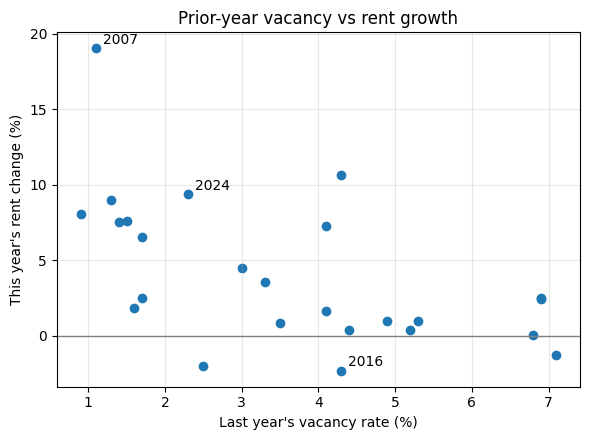

In [5]:
master["vacancy_lag1"] = master["vacancy_rate"].shift(1)
paired = master.dropna(subset=["vacancy_lag1", "rent_change_pct"])
correlation = np.corrcoef(paired["vacancy_lag1"], paired["rent_change_pct"])[0, 1]
print(f"Correlation (last year's vacancy vs this year's % rent change): {correlation:.2f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(paired["vacancy_lag1"], paired["rent_change_pct"])
for _, row in paired[paired["year"].isin([2007, 2016, 2024])].iterrows():
    ax.annotate(int(row["year"]), (row["vacancy_lag1"], row["rent_change_pct"]),
                xytext=(5, 3), textcoords="offset points")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Prior-year vacancy vs rent growth")
ax.set_xlabel("Last year's vacancy rate (%)")
ax.set_ylabel("This year's rent change (%)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Context series not yet in the model

Population (2001–2025) and unemployment (2011–2025) are collected in `data/raw/` but not joined to the master dataset. Unemployment would shorten the training history by about ten years.

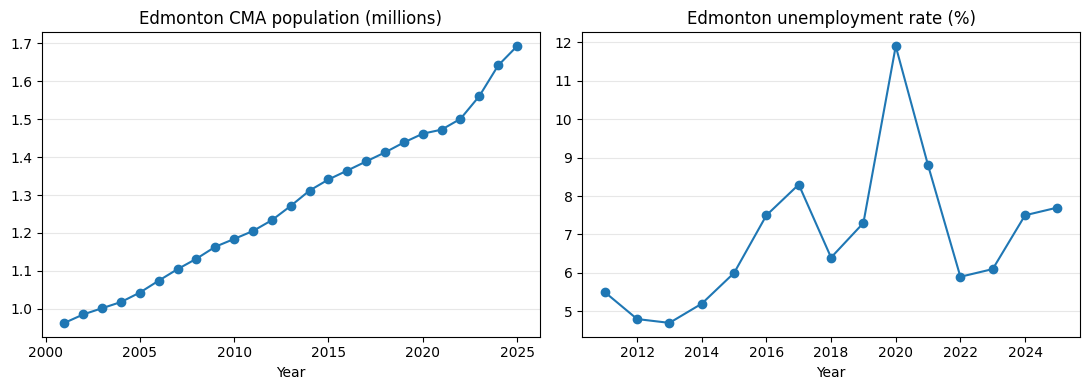

,year,value,annual_growth
20,2021,1472402.0,10705.0
21,2022,1500864.0,28462.0
22,2023,1560830.0,59966.0
23,2024,1641668.0,80838.0
24,2025,1692385.0,50717.0


In [6]:
def read_statcan_row(path: Path, label: str) -> pd.DataFrame:
    """Read one geography row from a wide Statistics Canada CSV export."""
    with path.open(encoding="utf-8-sig", newline="") as source:
        rows = list(csv.reader(source))
    header = next(row for row in rows if len(row) > 2 and row[0].startswith("Geography"))
    values = next(row for row in rows if row and row[0] == label)
    years = [int(year) for year in header[1:] if year.strip().isdigit()]
    numbers = [float(value.replace(",", "")) for value in values[1:len(years) + 1]]
    return pd.DataFrame({"year": years, "value": numbers})


raw = PROJECT_ROOT / "data" / "raw"
population = read_statcan_row(raw / "statcan_population.csv", "Edmonton (CMA), Alberta")
unemployment = read_statcan_row(raw / "statcan_unemployment.csv", "Edmonton, Alberta")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(population["year"], population["value"] / 1e6, marker="o")
left.set_title("Edmonton CMA population (millions)")
right.plot(unemployment["year"], unemployment["value"], marker="o")
right.set_title("Edmonton unemployment rate (%)")
for axis in (left, right):
    axis.set_xlabel("Year")
    axis.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

population.assign(annual_growth=population["value"].diff()).tail(5)

## Findings

- Rent rose from \$603 (2000) to \$1,598 (2025), about 4% a year compounded, but in bursts rather than smoothly.
- The 2023–2025 increase (+\$295) exceeds the total increase from 2014 to 2022.
- Last year's vacancy rate is negatively correlated with this year's rent growth, so it is included as `vacancy_lag1` in the forecasting model.
- Population growth accelerated after 2022, which is a natural next feature to test.